## 딥러닝 기반 텍스트 분류 : BERT 기반 모델 활용

**실습 목표:**

1. BERT 모델의 핵심 개념(사전학습, 파인튜닝)을 이해할 수 있다
2. Hugging Face 파이프라인으로 감성 분류를 수행할 수 있다
3. 분류 결과를 정량적으로 평가(Accuracy, F1, 혼동행렬)할 수 있다
4. 텍스트 분류 모델을 훈련할 수 있다

In [2]:
# 필요한 패키지를 설치합니다 (torch는 CPU 전용 경량 버전)
# !pip install -q transformers datasets scikit-learn matplotlib seaborn tqdm torchinfo
# !pip install -q torch --index-url https://download.pytorch.org/whl/cpu

# uv 권장! uv 환경에서는 위 pip 대신 터미널에서 uv sync 명령어로 설치하세요:
# uv sync

In [3]:
# ========================================
# 필요한 라이브러리를 불러옵니다
# ========================================

import platform
from pprint import pprint
import pandas as pd                # 데이터프레임 처리
import numpy as np                 # 수치 계산
import matplotlib.pyplot as plt    # 시각화
import seaborn as sns              # 고급 시각화 (혼동행렬 히트맵 등)
from tqdm import tqdm              # 진행률 표시 바
import torch                       # PyTorch (딥러닝 프레임워크)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score  # 평가 지표
from transformers import pipeline  # HuggingFace 파이프라인 (모델을 쉽게 사용)
from torchinfo import summary  # 모델 구조 요약 (파라미터 수, 레이어별 크기)
import warnings
warnings.filterwarnings('ignore')  # 불필요한 경고 메시지 숨기기

# ========================================
# 운영체제별 한글 폰트 설정
# ========================================
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


### 성능 이슈! 
### 텍스트 분류 --> 딥러닝을 쓰면 성능이 좋다!
### => 전통적인 머신러닝으로 기초부터 배울 시간이 없다
# 전통적인 텍스트 딥러닝
# RNN (순환신경망!) -> LSTM -> Transformer 모델 (2017, Google) -> Transformer Encoder더와 Decoder
# Transformer Encoder(정보를 압축==> 분류를 하겠음!)만 활용한 모델 BERT 모델
# Transformer Decoder(정보를 해석 및 생성)만 활용한 모델 GPT 모델 (ChatGPT, Cluade, Gemini)

### 1. BERT 모델 개요

**1회차 복습: TF-IDF의 한계를 떠올려볼까요?**

1회차에서 배운 TF-IDF는 단어의 **빈도** 를 기반으로 텍스트를 분석했습니다.
하지만 TF-IDF는 단어의 **문맥** 을 이해하지 못한다는 한계가 있습니다.

| 문장 | TF-IDF가 보는 것 | 실제 의미 |
|------|------------|----------|
| "이 영화 **재미없다**" | "재미" => 긍정? | 부정! |
| "이 영화 **재미있다**" | "재미" => 긍정? | 긍정! |
| "연기가 **좋지 않다**" | "좋" => 긍정? | 부정! |

=> TF-IDF는 개별 단어만 보기 때문에 **부정 표현, 문맥 의존적 의미** 를 놓칩니다.

---

**그래서 등장한 BERT!**

**BERT (Bidirectional Encoder Representations from Transformers)** 는 Google이 2018년에 발표한 모델로, 텍스트의 **문맥을 양방향으로 이해** 할 수 있습니다.

BERT의 핵심을 3줄로 요약하면:
1. **사전학습 (Pre-training)**: 위키피디아 등 대규모 텍스트로 언어의 일반적인 패턴을 미리 학습합니다
2. **파인튜닝 (Fine-tuning)**: 감성 분류 등 특정 과제에 맞게 추가 학습합니다
3. **양방향 문맥 이해**: 단어의 왼쪽과 오른쪽 문맥을 동시에 고려합니다

![BERT 모델](https://img1.daumcdn.net/thumb/R1280x0.fpng/?fname=http://t1.daumcdn.net/brunch/service/user/89Ls/image/8j3QuCRwMnFcwzxoymD6tgkHbPU.png)
![Transformer 모델](https://img1.daumcdn.net/thumb/R1280x0.fpng/?fname=http://t1.daumcdn.net/brunch/service/user/aPda/image/9MwX8YqNCz1s2-OnfBPGUIblnBE.png)

---

In [4]:
###  나는 밤을 먹었다
###  나는 밤에 잤다

![BERT 사전학습과 파인튜닝](images/2_bert_pretrain_finetune.png)

---

### [Hugging Face란?](https://huggingface.co/)

**Hugging Face** 는 AI 모델을 공유하고 사용할 수 있는 **오픈소스 플랫폼** 입니다.
개발자들이 GitHub에서 코드를 공유하듯, AI 연구자들은 Hugging Face에서 학습된 모델을 공유합니다.

| 구성 요소 | 역할 | 비유 |
|-----------|------|------|
| **Models Hub** | 100만+ 학습된 모델을 검색/다운로드 | 앱스토어 (원하는 모델을 골라 받는 곳) |
| **Datasets** | 공개 데이터셋을 검색/다운로드 | 공공 데이터 포털 (학습용 데이터 다운 가능) |
| **transformers** 라이브러리 | Hub의 모델을 Python에서 불러와 실행하는 도구 | 앱 플레이어 (받은 모델을 실제로 돌리는 도구) |
| **pipeline()** API | 모델 사용을 한 줄로 단순화 | 모델 로드 => 전처리 => 추론 => 후처리를 한 줄로 처리  |

---

[**Pipeline이란?**](https://huggingface.co/docs/transformers/main_classes/pipelines)

Hugging Face의 `pipeline()`은 **모델 + 토크나이저를 한 줄로** 사용할 수 있게 해주는 편리한 도구입니다.

```python
# 이 한 줄이 내부적으로 수행하는 작업:
classifier = pipeline("sentiment-analysis")

# 1. 토크나이저 로드 => 텍스트를 숫자(토큰)로 변환
# 2. 모델 로드 => 토큰을 입력받아 예측 수행
# 3. 후처리 => 예측 결과를 사람이 읽기 쉬운 형태로 변환
```

**이번 실습에서 사용하는 방법:**

```python
# transformers 라이브러리의 pipeline => 모델을 한 줄로 사용
from transformers import pipeline
classifier = pipeline("sentiment-analysis", model="모델이름")

# 사용 예시
result = classifier("이 영화 정말 재밌어요!")
# => [{'label': '1', 'score': 0.9875}]  (1=긍정, 0=부정)
```

---

**모델은 어떻게 찾을까요?**

1. https://huggingface.co/models 에 접속합니다
2. Task 필터에서 **Text Classification** 을 선택합니다
3. Language 필터에서 데이터 셋에 맞는 언어(예: **Korean**) 을 선택합니다
4. 원하는 세부 작업을 검색창에 입력합니다 (예: 감성 분석이면 `sentiment`, 스팸 분류면 `spam`)
5. 후보 모델의 **모델 카드**에서 평가 지표(Accuracy, F1 등)를 확인합니다
6. 다운로드 수, 좋아요 수도 함께 참고하여 검증된 모델을 선택합니다

> **핵심:** Hugging Face 덕분에 대규모 AI 모델을 직접 학습하지 않아도, 이미 학습된 모델을 `pipeline()` 한 줄로 바로 사용할 수 있습니다.

### 2. 환경 설정 및 영어 감성 분류 체험

먼저 설치된 라이브러리 버전을 확인하고, 영어 감성 분류를 체험해봅시다.

In [5]:
# 설치된 라이브러리 버전과 실행 환경을 확인합니다
import transformers

print(f"transformers 버전: {transformers.__version__}")
print(f"torch 버전: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"  GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("  => CPU 모드로 실행됩니다 (GPU보다 느리지만 실습에는 충분합니다)")

# 참고: 현재 torch는 CPU 전용 버전(torch+cpu)으로 설치되어 있습니다.
# GPU 버전 torch를 설치해도 CPU에서 동일하게 실행 가능하지만,
# CPU 전용 버전은 용량이 훨씬 작아(~150MB vs ~2.5GB) 현재 실습 환경에서 해당 버전을 이용했습니다.

transformers 버전: 5.3.0
torch 버전: 2.10.0+cpu
GPU 사용 가능: False
  => CPU 모드로 실행됩니다 (GPU보다 느리지만 실습에는 충분합니다)


**영어 감성 분류를 체험해볼까요?**

`pipeline("sentiment-analysis")`는 기본으로 영어 감성 분류 모델을 로드합니다.
먼저 영어 텍스트로 파이프라인 사용법을 익혀봅시다.

In [6]:
# ========================================
# 영어 감성 분류 파이프라인을 생성합니다
# pipeline() 한 줄로 모델 다운로드 + 로드가 자동으로 수행됩니다
# (처음 실행 시 모델 다운로드에 잠시 시간이 걸릴 수 있습니다)
# ========================================
# model= 을 지정하지 않으면 해당 과제의 기본 모델이 자동 선택됩니다 (출력 경고 메시지에서 모델을 확인할 수 있음)
en_classifier = pipeline("sentiment-analysis")

# 파이프라인 출력 구조를 자세히 살펴보겠습니다
results = en_classifier("This movie dislike great!")

print("[모델 출력 원본]")
pprint(results)

sample_result = results[0]
print("\n[파이프라인 출력 형태]")
print(f"  타입: {type(sample_result)}")   # dict (딕셔너리) 형태입니다
print(f"  내용: {sample_result}")
print(f"  라벨(label): {sample_result['label']}")     # POSITIVE 또는 NEGATIVE
print(f"  확신도(score): {sample_result['score']:.4f}")  # 0~1 사이 확률값
print()
print("* label: POSITIVE(긍정) 또는 NEGATIVE(부정)")
print("* score: 해당 라벨에 대한 모델의 확신도 (1에 가까울수록 확신)")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[모델 출력 원본]
[{'label': 'NEGATIVE', 'score': 0.9982134103775024}]

[파이프라인 출력 형태]
  타입: <class 'dict'>
  내용: {'label': 'NEGATIVE', 'score': 0.9982134103775024}
  라벨(label): NEGATIVE
  확신도(score): 0.9982

* label: POSITIVE(긍정) 또는 NEGATIVE(부정)
* score: 해당 라벨에 대한 모델의 확신도 (1에 가까울수록 확신)


In [7]:
# ========================================
# 모델 내부 구조를 확인해봅시다
# pipeline() 안에 숨겨진 모델의 레이어 구성을 볼 수 있습니다
# ========================================
print(en_classifier.model)

print()
print("[모델 파라미터 요약]")
print(summary(en_classifier.model, input_size=(1, 512), dtypes=[torch.long],
        col_names=["input_size", "output_size", "num_params", "trainable"]))


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


파라미터는 데이터의 양에 따라 결정되나요? 
아니면 태스크 난이도에 따라 결정되나요?

# => 둘다에 해당이 되고, 
# => 데이터의 양과 질

# ==> GPT같은 생성형 인공지능 ==> 성능을 올리기 위해 ==> 파라미터 사이즈 + 데이터의 양 (경험, 실험적!)
# ===> 성능이 개선이 됨!
# ==> 추론 단계 ==> 자기가 답변하고 --> 다시 답변을 토대로 다시 평가 -> 개선 --> 정확도를 높임!
# ===> AGentic AI가 발전을 함!

In [8]:
# 영어 예시 문장 5개를 준비합니다
en_sentences = [
    "This movie is absolutely fantastic! I loved every moment.",
    "Terrible film. Complete waste of time and money.",
    "The acting was decent but the plot was boring.",
    "One of the best movies I have ever seen!",
    "I fell asleep halfway through. So disappointing."
]

# 각 문장의 감성을 분류합니다
results = en_classifier(en_sentences) #배치처리 (여러 데이터를 한꺼번에 처리한다!)
print("[모델 출력 원본]")
pprint(results)

print("\n[영어 감성 분류 결과]")
print("=" * 70)
for sentence, result in zip(en_sentences, results):
    label = result['label']      # 예측 라벨: POSITIVE(긍정) 또는 NEGATIVE(부정)
    score = result['score']      # 확신도: 0~1 사이 (1에 가까울수록 확신)
    print("모델 출력 결과(원본):")
    print(f"문장: {sentence}")
    print(f"  => 예측: {label} (확신도: {score:.4f})")
    print("-" * 70)

[모델 출력 원본]
[{'label': 'POSITIVE', 'score': 0.9998871088027954},
 {'label': 'NEGATIVE', 'score': 0.999774158000946},
 {'label': 'NEGATIVE', 'score': 0.9987820982933044},
 {'label': 'POSITIVE', 'score': 0.9998704195022583},
 {'label': 'NEGATIVE', 'score': 0.9997709393501282}]

[영어 감성 분류 결과]
모델 출력 결과(원본):
문장: This movie is absolutely fantastic! I loved every moment.
  => 예측: POSITIVE (확신도: 0.9999)
----------------------------------------------------------------------
모델 출력 결과(원본):
문장: Terrible film. Complete waste of time and money.
  => 예측: NEGATIVE (확신도: 0.9998)
----------------------------------------------------------------------
모델 출력 결과(원본):
문장: The acting was decent but the plot was boring.
  => 예측: NEGATIVE (확신도: 0.9988)
----------------------------------------------------------------------
모델 출력 결과(원본):
문장: One of the best movies I have ever seen!
  => 예측: POSITIVE (확신도: 0.9999)
----------------------------------------------------------------------
모델 출력 결과(원본):
문장: I fell asleep

### 3. 한국어 감성 분류 적용

**한국어 감성 분류 모델을 사용해봅시다**

영어 모델은 한국어를 이해하지 못하므로, **한국어로 학습된 모델** 이 필요합니다.

| 모델 | 기반 아키텍처 | 학습 데이터 | 특징 |
|------|-------------|------------|------|
| `Copycats/koelectra-base-v3-generalized-sentiment-analysis` | KoELECTRA-v3 | 상품 리뷰 (범용) | 이진 감성 분류 특화 |
| `daekeun-ml/koelectra-small-v3-nsmc` | KoELECTRA-Small-v3 | NSMC (영화 리뷰) | 14M 경량 모델 |

이번 실습에서는 `Copycats/koelectra-base-v3-generalized-sentiment-analysis` 모델을 사용합니다.

**이 모델을 선택한 이유:**

| 기준 | 설명 |
|------|------|
| **한국어 전용** | KoELECTRA는 한국어 텍스트로만 사전학습된 모델입니다 |
| **감성 분류 파인튜닝 완료** | 이미 감성 분류 과제로 파인튜닝되어 있어 `pipeline()`으로 바로 사용 가능합니다 |
| **범용 학습 데이터** | 상품 리뷰 기반으로 학습되어 특정 도메인에 편향되지 않습니다 |
| **적절한 모델 크기** | 0.1B(약 400MB)로 GPU 없이 CPU 환경에서도 실행할 수 있습니다 |

---

**잠깐, ELECTRA는 BERT와 뭐가 다를까요?**

ELECTRA는 BERT와 같은 Transformer Encoder 구조이지만, **사전학습 방법** 이 다릅니다.

| 구분 | BERT | ELECTRA |
|------|------|---------|
| 학습 방식 | 단어를 [MASK]로 가리고 맞히기 | 가짜 단어를 넣고 진짜/가짜 판별 |
| 비유 | 빈칸 채우기 시험 | 틀린 그림 찾기 시험 |
| 학습 효율 | 한 문장에서 [MASK]된 토큰(약 15%)만 학습에 활용 | 한 문장의 모든 토큰을 학습에 활용 |
| 결과 | 같은 크기에서 ELECTRA가 더 높은 성능 | |

> **참고:** 여기서 "15%"란 학습 데이터의 15%가 아니라, 한 문장 안에서 [MASK] 처리되는 **토큰의 비율** 을 의미합니다. 예를 들어 10개 단어로 이루어진 문장이라면, BERT는 그 중 1~2개만 가려서 맞히지만, ELECTRA는 10개 전부를 진짜/가짜 판별 대상으로 활용합니다. 따라서 같은 양의 데이터를 학습해도 ELECTRA가 더 효율적입니다.

=> 구조는 같기 때문에 사용법도 BERT와 동일하게 `pipeline()`으로 간편하게 사용할 수 있습니다.

In [9]:
# ========================================
# 한국어 감성 분류 파이프라인을 생성합니다
# KoELECTRA 기반 범용 감성 분류 모델을 사용합니다
# (처음 실행 시 모델 다운로드에 1~2분 정도 걸릴 수 있습니다)
# ========================================
ko_classifier = pipeline(
    "sentiment-analysis",                                                    # 과제: 감성 분류
    model="Copycats/koelectra-base-v3-generalized-sentiment-analysis",       # KoELECTRA 감성 분류 모델
    tokenizer="Copycats/koelectra-base-v3-generalized-sentiment-analysis",   # 같은 모델의 토크나이저
    truncation=True                                                          # 긴 텍스트 자동 잘라내기
)

print("한국어 감성 분류 모델 로드 완료")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: Copycats/koelectra-base-v3-generalized-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


한국어 감성 분류 모델 로드 완료


In [10]:
# ko_classifier 모델의 내부 구조를 확인합니다 (KoELECTRA-Base, 0.1B)
# (electra): Encoder 본체 - 사전학습된 언어 이해 부분
# (classifier): 분류 헤드 - 감성 분류를 수행하는 출력 부분
print(ko_classifier.model)

print()
print("[모델 파라미터 요약]")
print(summary(ko_classifier.model, input_size=(1, 512), dtypes=[torch.long],
        col_names=["input_size", "output_size", "num_params", "trainable"]))


ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(35000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [11]:
# 한국어 문장으로 감성 분류를 테스트합니다
ko_sentences = [
    "이 영화 진짜 재밌어요! 강력 추천합니다.",
    "배우들 연기가 너무 좋았고 스토리도 감동적이었습니다.",
    "최고의 영화입니다. 두 번 봐도 좋아요.",
    "시간 낭비했다. 스토리가 너무 지루함.",
    "연기도 별로고 내용도 엉망이네요.",
    "돈이 아깝다. 최악의 영화."
]

# 리스트를 한번에 넘겨서 배치 추론합니다
results = ko_classifier(ko_sentences)
print("[모델 출력 원본]")
pprint(results)

print("\n[한국어 감성 분류 결과]")
print("=" * 70)
for sentence, result in zip(ko_sentences, results):
    label = result['label']
    score = result['score']
    # 모델 출력 라벨을 한국어로 변환합니다
    label_kr = "긍정" if "1" in label or "POS" in label.upper() else "부정"
    print(f"문장: {sentence}")
    print(f"  => 예측: {label_kr} ({label}, 확신도: {score:.4f})")
    print("-" * 70)

[모델 출력 원본]
[{'label': '1', 'score': 0.9875041842460632},
 {'label': '1', 'score': 0.9939976930618286},
 {'label': '1', 'score': 0.9906914830207825},
 {'label': '0', 'score': 0.9986767172813416},
 {'label': '0', 'score': 0.9989147186279297},
 {'label': '0', 'score': 0.9988768696784973}]

[한국어 감성 분류 결과]
문장: 이 영화 진짜 재밌어요! 강력 추천합니다.
  => 예측: 긍정 (1, 확신도: 0.9875)
----------------------------------------------------------------------
문장: 배우들 연기가 너무 좋았고 스토리도 감동적이었습니다.
  => 예측: 긍정 (1, 확신도: 0.9940)
----------------------------------------------------------------------
문장: 최고의 영화입니다. 두 번 봐도 좋아요.
  => 예측: 긍정 (1, 확신도: 0.9907)
----------------------------------------------------------------------
문장: 시간 낭비했다. 스토리가 너무 지루함.
  => 예측: 부정 (0, 확신도: 0.9987)
----------------------------------------------------------------------
문장: 연기도 별로고 내용도 엉망이네요.
  => 예측: 부정 (0, 확신도: 0.9989)
----------------------------------------------------------------------
문장: 돈이 아깝다. 최악의 영화.
  => 예측: 부정 (0, 확신도: 0.9989)
----------

**1회차 전처리 vs BERT, 왜 다를까요?**

1회차에서는 TF-IDF 분석을 위해 5단계 전처리 파이프라인을 구축했습니다.

| 단계 | 1회차 (TF-IDF) | 2회차 (BERT) |
|------|---------------|-------------|
| (1) 정제 (HTML, 특수문자 제거) | O | X |
| (2) 정규화 (대소문자 통일 등) | O | X |
| (3) 형태소 분석 (Kiwi) | O | X |
| (4) 불용어 제거 | O | X |
| (5) 결측치/빈 문자열 제거 | O | O |

=> BERT/ELECTRA에서는 (1)~(4)를 **의도적으로 생략** 합니다. 그 이유는:

1. **자체 토크나이저 내장**: BERT 계열 모델은 자체 서브워드 토크나이저(WordPiece, SentencePiece 등)가 포함되어 있어 외부 형태소 분석기가 필요 없습니다. 이번 실습의 KoELECTRA는 SentencePiece 기반 토크나이저를 사용합니다
2. **불용어가 문맥의 일부**: "좋지 **않다**"에서 "않다"를 제거하면 의미가 반대로 바뀝니다. BERT는 불용어까지 포함한 전체 문맥을 이해하므로 제거하면 오히려 성능이 떨어집니다
3. **사전학습 데이터와 일치**: BERT는 원본 텍스트로 사전학습되었기 때문에, 같은 형태의 입력을 넣어야 성능이 잘 나옵니다

| 방식 | 토큰화 방법 | 불용어 처리 | 입력 형태 |
|------|-----------|-----------|----------|
| TF-IDF | 외부 형태소 분석기 필요 | 직접 제거해야 함 | 전처리된 토큰 리스트 |
| BERT/ELECTRA | 자체 서브워드 토크나이저 | 제거하면 안 됨 (문맥 손실) | 원본 텍스트 그대로 |

> **핵심:** 모델에 따라 전처리 전략이 달라집니다. TF-IDF처럼 단어 빈도 기반 모델은 정교한 전처리가 필수지만, BERT처럼 문맥을 이해하는 딥러닝 모델은 원본 텍스트를 그대로 넣는 것이 최선입니다.

In [12]:
# ========================================
# NSMC 테스트 데이터를 로드하여 본격적으로 평가합니다
# NSMC(Naver Sentiment Movie Corpus): 네이버 영화 리뷰 감성 분류 데이터셋
# 원본 출처: https://github.com/e9t/nsmc
# ========================================

# data 폴더의 NSMC 테스트 데이터(5만건)를 로드합니다
df_test = pd.read_csv("data/ratings_test.txt", sep="\t")

# 데이터 정리: 결측치와 빈 문자열을 제거합니다
df_test = df_test.dropna(subset=['document'])
df_test = df_test[df_test['document'].str.strip() != ''].reset_index(drop=True)

print(f"[전체 테스트 데이터] {len(df_test):,}건")
print(f"  긍정: {(df_test['label'] == 1).sum():,}건")
print(f"  부정: {(df_test['label'] == 0).sum():,}건")

# 200건만 랜덤 샘플링합니다 (전체를 돌리면 시간이 오래 걸리므로)
df_sample = df_test.sample(n=200, random_state=42).reset_index(drop=True)

print(f"\n[샘플링 완료] {len(df_sample)}건")
print(f"  긍정: {(df_sample['label'] == 1).sum()}건")
print(f"  부정: {(df_sample['label'] == 0).sum()}건")
display(df_sample.head())

[전체 테스트 데이터] 49,997건
  긍정: 25,171건
  부정: 24,826건

[샘플링 완료] 200건
  긍정: 102건
  부정: 98건


,id,document,label
0,5531942,찐한 여운과 함께...내 인생 최고의 미드,1
1,4592330,기대 이상이다,1
2,7415980,신날 것 없는 애니.,0
3,6351218,마지막까지 힘을잃지않은 드라마~~,1
4,8198149,정말아니다. 그냥 뒤끝이 불쾌하고 상황에 대처하는 언니와 순경을 보고 너무 비현실적...,0


In [ ]:
# ========================================
# 200건 전체를 한국어 모델로 배치 추론합니다
# pipeline()에 리스트를 넘기면 건별 루프보다 훨씬 빠릅니다
# ========================================

# 텍스트 리스트를 준비합니다 (결측치 방지를 위해 str 변환)
texts = df_sample['document'].astype(str).tolist()

print("200건 감성 분류 진행 중... (배치 추론)")
# batch_size=16: 한 번에 16건씩 묶어서 처리합니다 (건별 루프보다 빠름)
# truncation=True는 pipeline 생성 시 이미 설정했으므로 자동 적용됩니다
results = ko_classifier(texts, batch_size=16)  # batch_size 컴퓨터의 메모리에 맞게 설정!
# 컴퓨터 메모리가 크다 ! batch_size 를 키우면 됨! --> 빠르게 결과를 볼 수 있다! RAM
# gpu vram보다 ram과 연관이 있는 부분인가요?
# GPU를 쓰고 있으면 vram이 batchsize 크기를 결정!
# CPU를 쓰고 있으면 일반 RAM으로 batchsize 크기를 결정!
# 하드와 RAM의 차이?? =>
# 하드 : 비휘발성 (아직 실행되지 않은 파일 자체, 컴퓨터 끄면 안사라진다)
# 램 : 휘발성 (현재 실행중인 프로그램 및 파일, 컴퓨터 끄면 사라진다)

# 결과를 파싱합니다
predictions = []   # 예측 라벨(0 또는 1)을 저장할 리스트
confidences = []   # 확신도(0~1)를 저장할 리스트

for result in results:
    label = result['label']
    # 모델 출력 라벨을 0/1 숫자로 변환합니다
    if '1' in label or 'POS' in label.upper():
        pred = 1  # 긍정
    else:
        pred = 0  # 부정
    predictions.append(pred)
    confidences.append(result['score'])

# 결과를 DataFrame에 새로운 열로 추가합니다
df_sample['predicted'] = predictions    # 모델이 예측한 라벨
df_sample['confidence'] = confidences   # 모델의 확신도

print(f"분류 완료!")
display(df_sample[['document', 'label', 'predicted', 'confidence']].head(10))

200건 감성 분류 진행 중... (배치 추론)
분류 완료!


,document,label,predicted,confidence
0,찐한 여운과 함께...내 인생 최고의 미드,1,1,0.992984
1,기대 이상이다,1,1,0.959743
2,신날 것 없는 애니.,0,0,0.972705
3,마지막까지 힘을잃지않은 드라마~~,1,1,0.991208
4,정말아니다. 그냥 뒤끝이 불쾌하고 상황에 대처하는 언니와 순경을 보고 너무 비현실적...,0,0,0.998933
5,영화공사중 도로를 보았는데 에어컨을.. 정말 더웠다.하지만 더글라스오빠연기 압권,1,1,0.958324
6,덴젤 당신은 소름끼칩니다~~!,1,1,0.980306
7,음.. 괜찮네요. 생각보다 좋았어요,1,1,0.925039
8,"""21세기 """"레니 할린, 작품은 """"마인트헌터, 뿐인가!? 연출이 tv판 수준!""",0,0,0.959819
9,ㅋㅋ 이게뭐야,0,1,0.794491


### 4. 분류 결과 평가

**분류 모델을 어떻게 평가할까요?**

| 지표 | 의미 | 쉽게 말하면 |
|------|------|------------|
| **Accuracy** (정확도) | 전체 중 맞힌 비율 | 100문제 중 몇 개 맞혔는가? |
| **Precision** (정밀도) | 긍정이라고 예측한 것 중 실제 긍정 비율 | "긍정" 답안지 중 진짜 긍정은 몇 %인가? |
| **Recall** (재현율) | 실제 긍정 중 긍정이라고 예측한 비율 | 진짜 긍정을 얼마나 잘 찾아냈는가? |
| **F1-Score** | Precision과 Recall의 조화 평균 | 정밀도와 재현율의 균형 점수 |

**감성 분류에서는 어떤 지표를 봐야 할까요?**

감성 분류는 보통 긍정/부정이 비슷한 비율로 존재하므로 **Accuracy** 만으로도 충분한 경우가 많습니다. 하지만 상황에 따라 중요한 지표가 달라질 수 있습니다:

| 상황 | 우선 지표 | 이유 |
|------|----------|------|
| 긍정/부정 비율이 비슷할 때 | **Accuracy** | 전체 정답률만으로 성능을 충분히 파악 가능 |
| 부정 리뷰를 놓치면 안 될 때 (예: CS 대응) | **Recall** (부정 클래스) | 불만 고객을 놓치지 않는 것이 중요 |
| 긍정으로 잘못 분류하면 안 될 때 (예: 자동 추천) | **Precision** (긍정 클래스) | 잘못된 긍정 추천이 신뢰도를 떨어뜨림 |
| 클래스 비율이 불균형할 때 (예: 긍정 90%, 부정 10%) | **F1-Score** | Accuracy는 다수 클래스만 맞혀도 높게 나오므로 신뢰하기 어려움 |

> **이번 실습에서는** NSMC 데이터가 긍정/부정 약 50:50으로 균형 잡혀 있으므로 **Accuracy** 를 주요 지표로 봅니다. \
> 다만 실무에서는 데이터 비율이 항상 균형적이라는 보장이 없기 때문에, F1-Score를 함께 보고하는 것이 일반적인 관례입니다.

---

In [14]:
# ========================================
# 분류 성능 평가 리포트를 출력합니다
# ========================================

y_true = df_sample['label'].values       # 실제 정답 라벨
y_pred = df_sample['predicted'].values   # 모델이 예측한 라벨

print("[분류 성능 평가 리포트]")
print("=" * 60)
# classification_report (sklearn에서 제공됨): Precision, Recall, F1-Score를 한번에 보여줍니다
print(classification_report(
    y_true, y_pred,
    target_names=['부정 (0)', '긍정 (1)'],  # 라벨 이름
    digits=4                                  # 소수점 4자리까지 표시
))

# 주요 지표를 요약합니다
acc = accuracy_score(y_true, y_pred)           # 전체 정확도
f1 = f1_score(y_true, y_pred, average='weighted')  # 가중 F1-Score
print(f"전체 정확도 (Accuracy): {acc:.4f} ({acc*100:.1f}%)")
print(f"가중 F1-Score: {f1:.4f}")

[분류 성능 평가 리포트]
              precision    recall  f1-score   support

      부정 (0)     0.9674    0.9082    0.9368        98
      긍정 (1)     0.9167    0.9706    0.9429       102

    accuracy                         0.9400       200
   macro avg     0.9420    0.9394    0.9398       200
weighted avg     0.9415    0.9400    0.9399       200

전체 정확도 (Accuracy): 0.9400 (94.0%)
가중 F1-Score: 0.9399


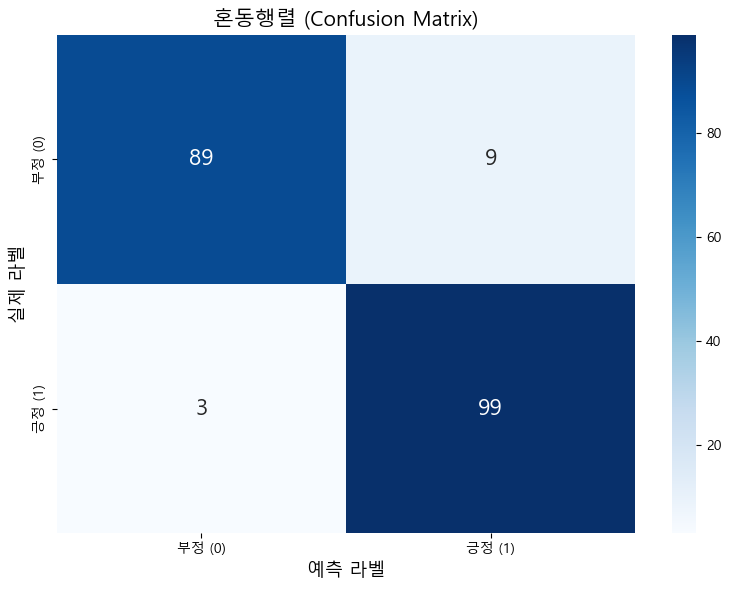

[O] TN (참 부정): 89건 - 부정을 부정으로 올바르게 예측
[O] TP (참 긍정): 99건 - 긍정을 긍정으로 올바르게 예측
[X] FP (거짓 긍정): 9건 - 부정인데 긍정으로 잘못 예측
[X] FN (거짓 부정): 3건 - 긍정인데 부정으로 잘못 예측


In [15]:
# ========================================
# 혼동행렬(Confusion Matrix)을 시각화합니다
# ========================================
cm = confusion_matrix(y_true, y_pred)  # 혼동행렬 계산

plt.figure(figsize=(8, 6))
# seaborn의 heatmap으로 색깔 있는 행렬을 그립니다
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',           # annot=True: 숫자 표시, fmt='d': 정수
    xticklabels=['부정 (0)', '긍정 (1)'],             # x축 라벨
    yticklabels=['부정 (0)', '긍정 (1)'],             # y축 라벨
    annot_kws={'size': 16}                            # 숫자 크기
)
plt.xlabel('예측 라벨', fontsize=13)
plt.ylabel('실제 라벨', fontsize=13)
plt.title('혼동행렬 (Confusion Matrix)', fontsize=15)
plt.tight_layout()
plt.show()

# 혼동행렬의 각 값을 해석합니다
tn, fp, fn, tp = cm.ravel()  # 2x2 행렬을 4개 값으로 펼칩니다
print(f"[O] TN (참 부정): {tn}건 - 부정을 부정으로 올바르게 예측")
print(f"[O] TP (참 긍정): {tp}건 - 긍정을 긍정으로 올바르게 예측")
print(f"[X] FP (거짓 긍정): {fp}건 - 부정인데 긍정으로 잘못 예측")
print(f"[X] FN (거짓 부정): {fn}건 - 긍정인데 부정으로 잘못 예측")

### 5. 다양한 모델 비교 (선택 실습)

다른 한국어 모델과 성능을 비교해볼까요?

**비교 대상 모델:**

| 모델 | 기반 아키텍처 | 학습 데이터 | 특징 |
|------|-------------|------------|------|
| `Copycats/koelectra-base-v3-generalized-sentiment-analysis` | KoELECTRA-v3 (0.1B) | 상품 리뷰 (범용) | 범용 감성 분류 |
| `daekeun-ml/koelectra-small-v3-nsmc` | KoELECTRA-Small-v3 (14M) | NSMC (영화 리뷰) | NSMC 파인튜닝, 경량 모델 |

=> 같은 ELECTRA 계열이지만 **모델 크기** 와 **학습 데이터** 가 다릅니다. 크기가 클수록 성능이 좋을까요?

> **공정성 참고:** `daekeun-ml` 모델은 NSMC 학습 데이터로 파인튜닝된 모델이고, 우리가 평가에 사용하는 데이터도 NSMC 테스트셋입니다. \
> 즉, `daekeun-ml` 모델은 같은 도메인(영화 리뷰)의 데이터로 학습한 모델이므로 NSMC 평가에서 유리할 수 있습니다.  \
> 반면 `Copycats` 모델은 상품 리뷰 기반 범용 모델이므로 영화 리뷰에 최적화되어 있지 않습니다. 이 점을 감안하여 결과를 해석해야 합니다. \

In [16]:
# 두 번째 모델을 로드합니다 (KoELECTRA-Small, NSMC 파인튜닝 경량 모델)
ko_classifier_2 = pipeline(
    "sentiment-analysis",
    model="daekeun-ml/koelectra-small-v3-nsmc",
    tokenizer="daekeun-ml/koelectra-small-v3-nsmc",
    truncation=True                                    # 긴 텍스트 자동 잘라내기
)

print("두 번째 모델 로드 완료")

# ========================================
# 같은 200건 샘플을 두 번째 모델로 배치 추론합니다
# ========================================
texts = df_sample['document'].astype(str).tolist()

print("모델 2로 200건 감성 분류 진행 중... (배치 추론)")
results_2 = ko_classifier_2(texts, batch_size=16)

# 결과를 파싱합니다
predictions_2 = []
for result in results_2:
    label = result['label']
    if '1' in label or 'POS' in label.upper():
        pred = 1
    else:
        pred = 0
    predictions_2.append(pred)

df_sample['predicted_2'] = predictions_2
print("모델 2 분류 완료!")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: daekeun-ml/koelectra-small-v3-nsmc
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


두 번째 모델 로드 완료
모델 2로 200건 감성 분류 진행 중... (배치 추론)
모델 2 분류 완료!


In [17]:
# ko_classifier_2 모델의 내부 구조를 확인합니다 (KoELECTRA-Small, 14M)
print(ko_classifier_2.model)

print()
print("[모델 파라미터 요약]")
print(summary(ko_classifier_2.model, input_size=(1, 512), dtypes=[torch.long],
        col_names=["input_size", "output_size", "num_params", "trainable"]))


ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(35000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (embeddings_project): Linear(in_features=128, out_features=256, bias=True)
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Li

In [18]:
# ========================================
# 두 모델의 성능을 비교합니다
# ========================================

# 모델 1 성능
acc_1 = accuracy_score(y_true, df_sample['predicted'].values)
f1_1 = f1_score(y_true, df_sample['predicted'].values, average='weighted')

# 모델 2 성능
acc_2 = accuracy_score(y_true, df_sample['predicted_2'].values)
f1_2 = f1_score(y_true, df_sample['predicted_2'].values, average='weighted')

# 각 모델의 파라미터 수를 직접 계산합니다
params_1 = sum(p.numel() for p in ko_classifier.model.parameters()) / 1_000_000   #단위 M
params_2 = sum(p.numel() for p in ko_classifier_2.model.parameters()) / 1_000_000 #단위 M

# 비교 테이블 만들기
comparison = pd.DataFrame({
    '모델': ['KoELECTRA-base (Copycats)', 'KoELECTRA-small (daekeun-ml)'],
    '파라미터(M)': [params_1, params_2],
    'Accuracy': [f'{acc_1:.4f}', f'{acc_2:.4f}'],
    'F1-Score': [f'{f1_1:.4f}', f'{f1_2:.4f}']
})

print("[모델 성능 비교]")
print("=" * 60)
display(comparison)

[모델 성능 비교]


,모델,파라미터(M),Accuracy,F1-Score
0,KoELECTRA-base (Copycats),112.922882,0.9400,0.9399
1,KoELECTRA-small (daekeun-ml),14.122498,0.8800,0.8800


### 6. 직접 학습해보기: 랜덤 초기화 vs 파인튜닝 vs 동결

지금까지는 **이미 학습이 완료된 모델** 을 `pipeline()`으로 가져와서 바로 사용했습니다.
그런데 만약 우리가 **직접 모델을 학습** 시킨다면 어떤 결과가 나올까요?

이번 섹션에서는 세 가지 방식으로 모델을 직접 학습시켜 봅니다:

| 방식 | 설명 | 비유 |
|------|------|------|
| **6-1. 랜덤 초기화 학습** | 모델 구조만 가져오고, 가중치는 랜덤으로 시작하여 처음부터 학습 | 백지 상태에서 한국어를 배우는 외국인 |
| **6-2. 파인튜닝** | 사전학습된 가중치를 가져와서, 소량의 데이터로 추가 학습 | 한국어를 이미 아는 사람이 영화 리뷰 분석법을 배우는 것 |
| **6-3. Encoder 동결** | 사전학습된 가중치를 고정하고, 분류 헤드만 학습 | 한국어 실력은 그대로 두고 리뷰 분류만 배우는 것 |

=> 세 방식의 결과를 비교하면 **사전학습(Pre-training)이 왜 중요한지** 체감할 수 있습니다.

---

**실습 모델:** `monologg/koelectra-small-v3-discriminator` (14M 파라미터, CPU 실행 가능)

> **참고:** 이번 실습에서는 학습 시간을 줄이기 위해 경량 모델(Small)과 소량의 데이터를 사용합니다. 실무에서는 더 큰 모델과 더 많은 데이터를 사용하면 성능이 크게 향상됩니다.

# 쉬는 시간 3시 05분에 시작 하겠습니다~!

In [19]:
# ========================================
# 메모리 정리: 앞에서 사용한 모델들을 해제합니다
# (학습에 충분한 메모리를 확보하기 위해)
# ========================================
import gc

del en_classifier, ko_classifier, ko_classifier_2
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("기존 모델 메모리 해제 완료")

기존 모델 메모리 해제 완료


#### 6-0. 학습 환경 세팅

직접 모델을 학습시키려면 `pipeline()`만으로는 부족합니다. 섹션 2~5에서는 `pipeline()`이 토큰화부터 추론까지 **모든 것을 자동으로** 처리했지만, 학습(Training)에는 각 단계를 직접 구성해야 합니다.

**pipeline() vs 직접 학습의 차이:**

| | pipeline() (섹션 2~5) | 직접 학습 (섹션 6) |
|---|---|---|
| 토큰화 | 내부에서 자동 처리 | 직접 토큰화해서 숫자로 변환 |
| 데이터 형식 | 텍스트 리스트 그대로 전달 | `Dataset` 객체로 변환 필요 |
| 모델 사용 | 추론(예측)만 가능 | 학습 + 추론 모두 가능 |
| 학습 설정 | 불필요 | `TrainingArguments`로 하이퍼파라미터 지정 |

**데이터 준비 과정:**

```
텍스트 리스트 => HFDataset.from_dict() => .map(tokenize) => .set_format("torch") => Trainer에 전달
```

1. `HFDataset.from_dict()`: 텍스트와 라벨을 딕셔너리로 묶어 데이터셋 생성
2. `.map(tokenize)`: 모델 제공 토크나이저로 텍스트를 숫자(토큰 ID)로 일괄 변환
3. `.set_format("torch")`: 모델이 받을 수 있는 PyTorch 텐서 형식으로 변환하고, 필요한 컬럼(`input_ids`, `attention_mask`, `label`)만 선택


![image.png](https://towardsdatascience.com/wp-content/uploads/2024/09/1cIvfWG0gAUym7FPS5-gSqQ.png)


In [21]:
# ========================================
# 학습에 필요한 라이브러리를 추가로 불러옵니다
# ========================================
from transformers import (
    AutoTokenizer,                          # 토크나이저 자동 로드
    AutoModelForSequenceClassification,     # 분류 모델 자동 로드
    AutoConfig,                             # 모델 설정(구조) 로드
    Trainer,                                # HuggingFace 학습 도구
    TrainingArguments                       # 학습 하이퍼파라미터 설정
)
from datasets import Dataset as HFDataset  # HuggingFace 데이터셋 (커스텀 클래스 없이 사용)

# ========================================
# 사용할 모델과 학습 설정을 정의합니다
# ========================================
MODEL_NAME = "monologg/koelectra-small-v3-discriminator"  # 경량 KoELECTRA 모델 (사전학습을 완료한 가중치)
MAX_LENGTH = 64      # 토큰 최대 길이 (짧은 리뷰에 충분)
BATCH_SIZE = 4       # 한 번에 처리할 샘플 수 (CPU 메모리 절약)
EPOCHS = 3           # 전체 데이터를 몇 번 반복 학습할지
TRAIN_SIZE = 300     # 학습에 사용할 샘플 수 (CPU 환경이므로 소량 사용)

# ========================================
# 토크나이저를 로드합니다
# ========================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"토크나이저 로드 완료: {MODEL_NAME}")
print(f"어휘 사전 크기: {tokenizer.vocab_size:,}개")

# ========================================
# NSMC 학습 데이터를 로드합니다 (15만건 중 300건만 샘플링)
# ========================================
df_train = pd.read_csv("data/ratings_train.txt", sep="\t")
df_train = df_train.dropna(subset=['document'])
df_train = df_train[df_train['document'].str.strip() != ''].reset_index(drop=True)

# 학습용 300건 샘플링
df_train_sample = df_train.sample(n=TRAIN_SIZE, random_state=42).reset_index(drop=True)

print(f"\n[학습 데이터] {len(df_train_sample)}건")
print(f"  긍정: {(df_train_sample['label'] == 1).sum()}건")
print(f"  부정: {(df_train_sample['label'] == 0).sum()}건")

# 평가용 데이터는 앞서 사용한 df_sample (200건)을 그대로 사용합니다
print(f"\n[평가 데이터] {len(df_sample)}건 (섹션 3에서 사용한 동일 데이터)")

# ========================================
# HuggingFace Dataset으로 데이터셋을 생성합니다
# 커스텀 클래스 없이 딕셔너리 => Dataset 변환 => .map() 토큰화로 간단하게 처리합니다
# ========================================

# 텍스트와 라벨을 준비합니다
train_texts = df_train_sample['document'].astype(str).tolist()
train_labels = df_train_sample['label'].tolist()
eval_texts = df_sample['document'].astype(str).tolist()
eval_labels = df_sample['label'].tolist()

# 딕셔너리로 데이터셋을 생성합니다 (커스텀 클래스 정의 불필요!)
train_dataset = HFDataset.from_dict({"text": train_texts, "label": train_labels})
eval_dataset = HFDataset.from_dict({"text": eval_texts, "label": eval_labels})

# 토큰화 함수를 정의합니다
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

# MAX_LENGTH = 64의 텍스트 길이
# i am a boy [pad] [pad] [pad] [pad] [pad] 텍스트 길이 4
# 1 1  1  1   0   0   0  0  attention mask
# i dskjl ds dsjkl dsjklds  dsjklds  dsjdskl dskl sdjdskl d 텍스트 길이 64

# 그럼 결국 "max_length"랑 같은 길이로 모든 단어를 만들어주는 것인가요?
# => 모든 문장을 max_length로 맞추는 작업을 한다
# 토큰 나이저가 하는 역할!

# .map()으로 전체 데이터를 일괄 토큰화합니다
train_dataset = train_dataset.map(tokenize, batched=True)
eval_dataset = eval_dataset.map(tokenize, batched=True)

# Trainer가 인식할 수 있도록 포맷을 설정합니다
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
eval_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
# 
print(f"\n데이터셋 준비 완료!")
print(f"  학습 데이터: {len(train_dataset)}건")
print(f"  평가 데이터: {len(eval_dataset)}건")

print(train_dataset)


# ========================================
# 평가 지표 함수를 정의합니다
# ========================================
# Trainer가 평가 시 자동으로 호출하는 콜백 함수입니다
# eval_strategy="epoch" 설정과 함께 사용하면 매 에포크마다 자동 평가됩니다
def compute_metrics(eval_pred):
    """Trainer가 평가 시 호출하는 함수"""
    logits, labels = eval_pred                          # 모델 출력(logits)과 정답 라벨
    predictions = np.argmax(logits, axis=1)             # logits => 예측 클래스
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1}

print("평가 함수 정의 완료 (compute_metrics)")

토크나이저 로드 완료: monologg/koelectra-small-v3-discriminator
어휘 사전 크기: 35,000개

[학습 데이터] 300건
  긍정: 146건
  부정: 154건

[평가 데이터] 200건 (섹션 3에서 사용한 동일 데이터)


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]


데이터셋 준비 완료!
  학습 데이터: 300건
  평가 데이터: 200건
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 300
})
평가 함수 정의 완료 (compute_metrics)


In [22]:
# ========================================
# 토큰화 전후를 비교해봅시다
# 원본 텍스트가 어떤 숫자(토큰 ID)로 변환되는지 확인합니다
# ========================================
sample_text = train_texts[0]

print("[토큰화 전] 원본 텍스트")
print(f"  '{sample_text}'")

print()
print("[토큰화 후] 모델이 실제로 받는 입력")
sample_encoded = tokenizer(sample_text, truncation=True, padding="max_length", max_length=MAX_LENGTH)

# input_ids: 각 토큰을 숫자(ID)로 변환한 것
print(f"  input_ids (길이 {len(sample_encoded['input_ids'])}): {sample_encoded['input_ids'][:20]}...")

# attention_mask: 실제 토큰(1) vs 패딩(0)을 구분하는 마스크
print(f"  attention_mask: {sample_encoded['attention_mask'][:20]}...")

print()
print("[토큰 ID => 토큰 복원] 숫자가 어떤 단어 조각인지 확인")
tokens = tokenizer.convert_ids_to_tokens(sample_encoded['input_ids'])
print(f"  {tokens[:20]}...")

print()
print("[정리]")
print(f"  원본 텍스트:  '{sample_text}'")
print(f"  토큰 개수:    {sum(sample_encoded['attention_mask'])}개 (패딩 제외)")
print(f"  전체 길이:    {len(sample_encoded['input_ids'])}개 (MAX_LENGTH={MAX_LENGTH}로 패딩 포함)")
print(f"  => 모델은 숫자 리스트(input_ids)를 입력으로 받아 분류를 수행합니다")

[토큰화 전] 원본 텍스트
  '원본이 최고'

[토큰화 후] 모델이 실제로 받는 입력
  input_ids (길이 64): [2, 16214, 4007, 6557, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
  attention_mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...

[토큰 ID => 토큰 복원] 숫자가 어떤 단어 조각인지 확인
  ['[CLS]', '원본', '##이', '최고', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...

[정리]
  원본 텍스트:  '원본이 최고'
  토큰 개수:    5개 (패딩 제외)
  전체 길이:    64개 (MAX_LENGTH=64로 패딩 포함)
  => 모델은 숫자 리스트(input_ids)를 입력으로 받아 분류를 수행합니다


#### 6-1. 랜덤 초기화 학습 (From Scratch)

모델의 **구조(아키텍처)만** 가져오고, 가중치는 **랜덤 값으로 초기화** 합니다.
즉, 사전학습 없이 우리가 준비한 300건의 데이터만으로 처음부터 학습합니다.

```python
# 핵심 코드 설명
config = AutoConfig.from_pretrained(MODEL_NAME, num_labels=2)
# => 모델 구조 설정만 가져옵니다 (레이어 수, 히든 크기 등)

model = AutoModelForSequenceClassification.from_config(config)
# => from_config(): 구조만 사용하고 가중치는 랜덤 초기화
# => from_pretrained()와 달리 사전학습 가중치를 로드하지 않습니다
```

> **[AutoModel이란?](https://huggingface.co/docs/transformers/model_doc/auto)** 
- `AutoModelForSequenceClassification`은 모델 이름만 넣으면 해당 아키텍처(BERT, ELECTRA 등)에 맞는 분류 모델 클래스를 **자동으로 선택** 해주는 도구입니다. 

> **예상:** 300건이라는 적은 데이터로 14M 파라미터를 처음부터 학습하므로, 성능이 낮을 것으로 예상됩니다.

In [23]:
# ========================================
# 6-1. 랜덤 초기화 모델 생성 및 학습
# ========================================

# 모델 구조(config)만 가져옵니다 (가중치는 랜덤 초기화)
# num_labels=2: 출력 클래스 수 (0=부정, 1=긍정 => 2개)
# => 모델 맨 마지막 분류 레이어의 출력 노드 수를 결정합니다
config = AutoConfig.from_pretrained(MODEL_NAME, num_labels=2)
model_scratch = AutoModelForSequenceClassification.from_config(config)

total_params_scratch = sum(p.numel() for p in model_scratch.parameters()) # 모델의 전체 파라미터
train_params_scratch = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad) # 모델의 학습 가능한 파라미터

print(f"[랜덤 초기화 모델]")
print(f"  전체 파라미터: {total_params_scratch:,}개")
print(f"  학습 가능 파라미터: {train_params_scratch:,}개")
print(f"  => 모든 가중치가 랜덤 값으로 초기화되어 있습니다")

# 학습 하이퍼파라미터를 설정합니다
training_args_scratch = TrainingArguments(
    output_dir="./results_scratch",       # 학습 결과 저장 폴더
    num_train_epochs=EPOCHS,              # 3 에포크 (전체 데이터 훈련 횟수)
    per_device_train_batch_size=BATCH_SIZE,  # GPU/CPU 1개당 학습 배치 크기
    per_device_eval_batch_size=BATCH_SIZE,  # GPU/CPU 1개당 평가 배치 크기
    eval_strategy="epoch",                # 매 에포크마다 평가
    logging_strategy="epoch",             # 매 에포크마다 로그
    save_strategy="epoch",                # 매 에포크마다 체크포인트 저장
    report_to="none",                     # wandb 등 외부 리포트 비활성화
    dataloader_pin_memory=False,          # CPU 환경에서 메모리 절약
    gradient_accumulation_steps=4,        # 4스텝마다 가중치 업데이트 (배치 크기 4, 실질 배치=16)
    # (1) 모델 파라미터를 업데이트 하는 과정도 시간이 소요! 시간절약!
    # (2) 배치 크기를 키우면 모델의 수렴이 안정적임!

    gradient_checkpointing=True,          # 순전파 중간값을 저장하지 않고 역전파 시 재계산 (메모리 절약, 속도 느림. GPU 메모리 여유 있으면 False로 변경)
    seed=42,                              # 재현성을 위한 랜덤 시드
    load_best_model_at_end=True,          # 학습 종료 후 가장 성능 좋은 모델을 자동 로드
    metric_for_best_model="accuracy",     # 최적 모델 선택 기준 지표
)

# Trainer를 생성하고 학습을 시작합니다
trainer_scratch = Trainer(
    model=model_scratch,
    args=training_args_scratch,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics  # 평가 시 accuracy, f1 자동 계산
)

print()
print("랜덤 초기화 모델 학습 시작... (CPU 환경에서 약 3~5분 소요)")
trainer_scratch.train()
print("학습 완료!")

# 학습 로그에서 마지막 에포크의 평가 결과를 가져옵니다
# (eval_strategy="epoch" 설정으로 매 에포크마다 자동 평가된 결과입니다)
print()
print("[랜덤 초기화 모델 평가 결과]")
print("=" * 60)
eval_results_scratch = [log for log in trainer_scratch.state.log_history if "eval_accuracy" in log]
acc_scratch = eval_results_scratch[-1]["eval_accuracy"]
f1_scratch = eval_results_scratch[-1]["eval_f1"]
print(f"Accuracy: {acc_scratch:.4f} ({acc_scratch*100:.1f}%)")
print(f"F1-Score: {f1_scratch:.4f}")

# best 모델을 저장합니다 (load_best_model_at_end=True로 이미 best가 로드된 상태)
trainer_scratch.save_model("./best_model_scratch")
tokenizer.save_pretrained("./best_model_scratch")
print(f"Best 모델 저장 완료: ./best_model_scratch")

# 메모리 정리: 다음 모델 학습을 위해 현재 모델을 해제합니다
del model_scratch, trainer_scratch
gc.collect()

[랜덤 초기화 모델]
  전체 파라미터: 14,122,498개
  학습 가능 파라미터: 14,122,498개
  => 모든 가중치가 랜덤 값으로 초기화되어 있습니다

랜덤 초기화 모델 학습 시작... (CPU 환경에서 약 3~5분 소요)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.742308,0.697732,0.490000,0.322282
2,2.763247,0.696477,0.490000,0.322282
3,2.731718,0.695294,0.490000,0.322282


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

학습 완료!

[랜덤 초기화 모델 평가 결과]
Accuracy: 0.4900 (49.0%)
F1-Score: 0.3223


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best 모델 저장 완료: ./best_model_scratch


299

#### 6-2. 파인튜닝 (Fine-tuning)

이번에는 **사전학습된 가중치** 를 그대로 가져와서, 같은 300건으로 추가 학습합니다.
사전학습 과정에서 이미 한국어의 문법, 단어 의미, 문맥 패턴을 학습했으므로, 소량의 데이터만으로도 빠르게 적응할 수 있습니다.

```python
# 핵심 차이점
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
# => from_pretrained(): 사전학습된 가중치를 로드한 후 분류 헤드만 추가
# => 6-1의 from_config()와 이 한 줄만 다릅니다!
```

> **예상:** 사전학습된 언어 지식이 있으므로, 같은 300건으로도 랜덤 초기화보다 훨씬 좋은 성능을 보일 것입니다.

In [24]:
# ========================================
# 6-2. 사전학습 모델을 파인튜닝합니다
# ========================================

# 사전학습된 가중치를 로드합니다 (6-1과의 유일한 차이!)
model_finetune = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2   # 긍정/부정 2개 클래스
)

total_params_finetune = sum(p.numel() for p in model_finetune.parameters())
train_params_finetune = sum(p.numel() for p in model_finetune.parameters() if p.requires_grad)

print(f"[파인튜닝 모델]")
print(f"  전체 파라미터: {total_params_finetune:,}개")
print(f"  학습 가능 파라미터: {train_params_finetune:,}개")
print(f"  => 사전학습된 가중치가 로드되어 있습니다")
print(f"  => 한국어 위키, 뉴스 등으로 이미 언어 패턴을 학습한 상태입니다")

# 학습 하이퍼파라미터를 설정합니다 (6-1과 동일)
training_args_finetune = TrainingArguments(
    output_dir="./results_finetune",      # 학습 결과 저장 폴더
    num_train_epochs=EPOCHS,              # 3 에포크 (전체 데이터 훈련 횟수)
    per_device_train_batch_size=BATCH_SIZE,  # GPU/CPU 1개당 학습 배치 크기
    per_device_eval_batch_size=BATCH_SIZE,  # GPU/CPU 1개당 평가 배치 크기
    eval_strategy="epoch",                # 매 에포크마다 평가
    logging_strategy="epoch",             # 매 에포크마다 로그
    save_strategy="epoch",                # 매 에포크마다 체크포인트 저장
    report_to="none",                     # wandb 등 외부 리포트 비활성화
    dataloader_pin_memory=False,          # CPU 환경에서 메모리 절약
    gradient_accumulation_steps=4,        # 4스텝마다 가중치 업데이트 (실질 배치=16)
    gradient_checkpointing=True,          # 순전파 중간값을 저장하지 않고 역전파 시 재계산 (메모리 절약, 속도 느림. GPU 메모리 여유 있으면 False로 변경)
    seed=42,                              # 재현성을 위한 랜덤 시드
    load_best_model_at_end=True,          # 학습 종료 후 가장 성능 좋은 모델을 자동 로드
    metric_for_best_model="accuracy",     # 최적 모델 선택 기준 지표
)

trainer_finetune = Trainer(
    model=model_finetune,
    args=training_args_finetune,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics  # 평가 시 accuracy, f1 자동 계산
)

print()
print("파인튜닝 학습 시작... (CPU 환경에서 약 3~5분 소요)")
trainer_finetune.train()
print("학습 완료!")

# 학습 로그에서 마지막 에포크의 평가 결과를 가져옵니다
print()
print("[파인튜닝 모델 평가 결과]")
print("=" * 60)
eval_results_finetune = [log for log in trainer_finetune.state.log_history if "eval_accuracy" in log]
acc_finetune = eval_results_finetune[-1]["eval_accuracy"]
f1_finetune = eval_results_finetune[-1]["eval_f1"]
print(f"Accuracy: {acc_finetune:.4f} ({acc_finetune*100:.1f}%)")
print(f"F1-Score: {f1_finetune:.4f}")

# best 모델을 저장합니다
trainer_finetune.save_model("./best_model_finetune")
tokenizer.save_pretrained("./best_model_finetune")
print(f"Best 모델 저장 완료: ./best_model_finetune")

# 메모리 정리
del model_finetune, trainer_finetune
gc.collect()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-small-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missi

[파인튜닝 모델]
  전체 파라미터: 14,122,498개
  학습 가능 파라미터: 14,122,498개
  => 사전학습된 가중치가 로드되어 있습니다
  => 한국어 위키, 뉴스 등으로 이미 언어 패턴을 학습한 상태입니다

파인튜닝 학습 시작... (CPU 환경에서 약 3~5분 소요)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.740100,0.691088,0.535000,0.425342
2,2.722354,0.689989,0.615000,0.609891
3,2.709634,0.688801,0.625000,0.619100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

학습 완료!

[파인튜닝 모델 평가 결과]
Accuracy: 0.6250 (62.5%)
F1-Score: 0.6191


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best 모델 저장 완료: ./best_model_finetune


338

**LOAD REPORT 경고 해석**

위 실행 결과에서 `UNEXPECTED`, `MISSING` 경고가 뜨지만 **정상적인 동작** 입니다.

사전학습 모델(`discriminator`)과 분류 모델(`ForSequenceClassification`)의 **마지막 레이어 구조가 다르기 때문** 에 발생합니다:

| Status | 해당 레이어 | 의미 |
|---|---|---|
| **UNEXPECTED** | `discriminator_predictions.*` | 사전학습용 판별 헤드 => 분류에 불필요하므로 버림 |
| **MISSING** | `classifier.*` | 분류 헤드를 랜덤 초기화로 새로 생성 => 파인튜닝으로 학습 |

=> **ELECTRA Encoder 본체** 의 사전학습 가중치는 정상적으로 로드됩니다. 파인튜닝 시에는 이 Encoder 본체도 함께 미세 조정되고, 새로 생성된 분류 헤드는 처음부터 학습됩니다.

#### 6-3. Encoder 동결 학습 (Freeze)

파인튜닝의 변형으로, Encoder 본체의 가중치를 **동결(freeze)** 하고 분류 헤드만 학습하는 방식입니다.

| 방식 | Encoder 본체 | 분류 헤드 | 비유 |
|------|-------------|----------|------|
| 6-1. 랜덤 초기화 | 랜덤 => 학습 | 랜덤 => 학습 | 백지 상태에서 모든 것을 배움 |
| 6-2. 파인튜닝 | 사전학습 => **미세 조정** | 랜덤 => 학습 | 한국어를 아는 사람이 리뷰 분류를 배우며 한국어 실력도 다듬음 |
| 6-3. Encoder 동결 | 사전학습 => **고정 (학습 X)** | 랜덤 => 학습 | 한국어 실력은 그대로 두고 리뷰 분류만 배움 |

> **언제 사용할까?** 원래 모델의 원래 능력은 그대로 유지하면서, 데이터가 극소량이거나, 학습 시간을 줄이고 싶거나, 과적합을 방지하고 싶을 때 유용합니다.

In [ ]:
# ========================================
# 6-3. Encoder 동결(Freeze) 학습
# ========================================

# 사전학습된 모델을 로드합니다
model_freeze = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# Encoder 본체(electra)의 모든 파라미터를 동결합니다
# requires_grad=False => 역전파 시 가중치가 업데이트되지 않음
for param in model_freeze.electra.parameters():
    param.requires_grad = False

# [참고] 특정 레이어만 동결하고 싶은 경우 (아래는 예시이므로 주석 처리)
# --- Embedding만 동결 (나머지 Encoder 레이어는 학습) ---
# for param in model_freeze.electra.embeddings.parameters():
#     param.requires_grad = False

# --- 특정 Encoder 레이어만 동결 (예: 0~3번 레이어만 동결, 4번 이후는 학습) ---
# for i in range(4):
#     for param in model_freeze.electra.encoder.layer[i].parameters():
#         param.requires_grad = False

# 동결 후 학습 가능한 파라미터 수를 확인합니다
total_params_freeze = sum(p.numel() for p in model_freeze.parameters())
train_params_freeze = sum(p.numel() for p in model_freeze.parameters() if p.requires_grad)
frozen_params = total_params_freeze - train_params_freeze

print(f"[Encoder 동결 모델]")
print(f"  전체 파라미터: {total_params_freeze:,}개")
print(f"  동결 파라미터: {frozen_params:,}개 (Encoder 본체 - 학습 X)")
print(f"  학습 파라미터: {train_params_freeze:,}개 (분류 헤드만 학습)")
print(f"  => 전체의 {train_params_freeze/total_params_freeze*100:.2f}%만 학습합니다")

# 모델 구조를 확인합니다 (6-2와 동일한 구조, Encoder 본체만 동결됨)
# 구조는 같지만 requires_grad=False로 설정된 파라미터는 학습되지 않습니다
print()
print(model_freeze)
print("[모델 구조 요약 - 동결된 파라미터는 Trainable=False로 표시]")
print(summary(model_freeze, input_size=(1, MAX_LENGTH), dtypes=[torch.long],
        col_names=["input_size", "output_size", "num_params", "trainable"]))

# 학습 하이퍼파라미터를 설정합니다 (6-1과 동일, gradient_checkpointing만 제외)
training_args_freeze = TrainingArguments(
    output_dir="./results_freeze",        # 학습 결과 저장 폴더
    num_train_epochs=10,              # 3 에포크 (전체 데이터 훈련 횟수)
    per_device_train_batch_size=BATCH_SIZE,  # GPU/CPU 1개당 학습 배치 크기
    per_device_eval_batch_size=BATCH_SIZE,  # GPU/CPU 1개당 평가 배치 크기
    eval_strategy="epoch",                # 매 에포크마다 평가
    logging_strategy="epoch",             # 매 에포크마다 로그
    save_strategy="epoch",                # 매 에포크마다 체크포인트 저장
    report_to="none",                     # wandb 등 외부 리포트 비활성화
    dataloader_pin_memory=False,          # CPU 환경에서 메모리 절약
    gradient_accumulation_steps=4,        # 4스텝마다 가중치 업데이트 (실질 배치=16)
    seed=42,                              # 재현성을 위한 랜덤 시드
    load_best_model_at_end=True,          # 학습 종료 후 가장 성능 좋은 모델을 자동 로드
    metric_for_best_model="accuracy",     # 최적 모델 선택 기준 지표
    # gradient_checkpointing은 동결 시 불필요하므로 제외
)

trainer_freeze = Trainer(
    model=model_freeze,
    args=training_args_freeze,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics  # 평가 시 accuracy, f1 자동 계산
)

print()
print("Encoder 동결 모델 학습 시작... (분류 헤드만 학습하므로 더 빠릅니다)")
trainer_freeze.train()
print("학습 완료!")

# 학습 로그에서 마지막 에포크의 평가 결과를 가져옵니다
print()
print("[Encoder 동결 모델 평가 결과]")
print("=" * 60)
eval_results_freeze = [log for log in trainer_freeze.state.log_history if "eval_accuracy" in log]
acc_freeze = eval_results_freeze[-1]["eval_accuracy"]
f1_freeze = eval_results_freeze[-1]["eval_f1"]
print(f"Accuracy: {acc_freeze:.4f} ({acc_freeze*100:.1f}%)")
print(f"F1-Score: {f1_freeze:.4f}")

# best 모델을 저장합니다
trainer_freeze.save_model("./best_model_freeze")
tokenizer.save_pretrained("./best_model_freeze")
print(f"Best 모델 저장 완료: ./best_model_freeze")

# 메모리 정리
del model_freeze, trainer_freeze
gc.collect()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-small-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missi

[Encoder 동결 모델]
  전체 파라미터: 14,122,498개
  동결 파라미터: 14,056,192개 (Encoder 본체 - 학습 X)
  학습 파라미터: 66,306개 (분류 헤드만 학습)
  => 전체의 0.47%만 학습합니다

ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(35000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (embeddings_project): Linear(in_features=128, out_features=256, bias=True)
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.740418,0.692323,0.510000,0.344503
2,2.735261,0.692267,0.585000,0.570278
3,2.733381,0.692255,0.495000,0.384867
4,2.733236,0.692193,0.505000,0.370088
5,2.731004,0.692008,0.495000,0.378438
6,2.732509,0.692079,0.490000,0.322282
7,2.727979,0.691946,0.500000,0.352201
8,2.726734,0.691891,0.500000,0.352201
9,2.726496,0.691858,0.500000,0.352201
10,2.727363,0.691869,0.495000,0.341666


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

학습 완료!

[Encoder 동결 모델 평가 결과]
Accuracy: 0.4950 (49.5%)
F1-Score: 0.3417


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best 모델 저장 완료: ./best_model_freeze


362

<!-- 인코더 동결은 과적합때매 쓰는 건가요? -->
# => (1) 과적합 보다는 적은 메모리를 사용해서 빠른 훈련를 하기 위함! 
# => (2) 모델의 기존 성능을 유지하는 측면 (모델의 가중치를 고정! ==> 헤더를 통해 필요한 능력만 따로 학습!)

[4가지 방식 성능 비교]


,방식,가중치 초기화,학습 대상,Accuracy,F1-Score
0,Pipeline (사전학습+파인튜닝 완료 모델),사전학습+감성분류 학습 완료,없음 (추론만),0.9400,0.9399
1,6-1. 랜덤 초기화 (300건 학습),랜덤,전체,0.4900,0.3223
2,6-2. 파인튜닝 (300건 학습),사전학습,전체,0.6250,0.6191
3,6-3. Encoder 동결 (300건 학습),사전학습 (Encoder 고정),분류 헤드만,0.4950,0.3417


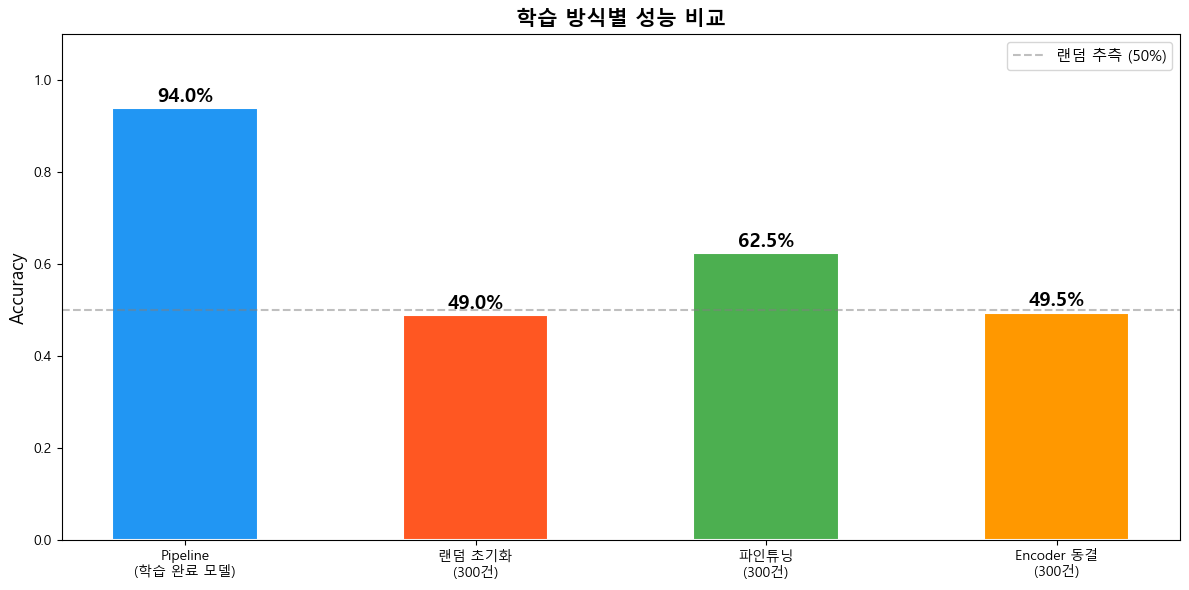

In [30]:
# ========================================
# 4가지 방식의 성능을 비교합니다
# ========================================

# 섹션 3~5에서 측정한 pipeline 모델 성능
acc_pipeline = accuracy_score(y_true, df_sample['predicted'].values)
f1_pipeline = f1_score(y_true, df_sample['predicted'].values, average='weighted')

# Pipeline 모델의 파라미터 수 (섹션 5의 비교에서 계산한 값 재사용)
# total_params_pipeline = sum(p.numel() for p in ko_classifier.model.parameters())
# train_params_pipeline = total_params_pipeline  # Pipeline 모델은 전체가 학습된 상태

# 비교 테이블 생성
comparison_all = pd.DataFrame({
    '방식': [
        'Pipeline (사전학습+파인튜닝 완료 모델)',
        '6-1. 랜덤 초기화 (300건 학습)',
        '6-2. 파인튜닝 (300건 학습)',
        '6-3. Encoder 동결 (300건 학습)'
    ],
    '가중치 초기화': ['사전학습+감성분류 학습 완료', '랜덤', '사전학습', '사전학습 (Encoder 고정)'],
    '학습 대상': ['없음 (추론만)', '전체', '전체', '분류 헤드만'],
    # '전체 파라미터': [f'{total_params_pipeline:,}', f'{total_params_scratch:,}', f'{total_params_finetune:,}', f'{total_params_freeze:,}'],
    # '학습 파라미터': [f'{train_params_pipeline:,}', f'{train_params_scratch:,}', f'{train_params_finetune:,}', f'{train_params_freeze:,}'],
    'Accuracy': [f'{acc_pipeline:.4f}', f'{acc_scratch:.4f}', f'{acc_finetune:.4f}', f'{acc_freeze:.4f}'],
    'F1-Score': [f'{f1_pipeline:.4f}', f'{f1_scratch:.4f}', f'{f1_finetune:.4f}', f'{f1_freeze:.4f}']
})

print("[4가지 방식 성능 비교]")
print("=" * 60)
display(comparison_all)

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
labels = ['Pipeline\n(학습 완료 모델)', '랜덤 초기화\n(300건)', '파인튜닝\n(300건)', 'Encoder 동결\n(300건)']
acc_values = [acc_pipeline, acc_scratch, acc_finetune, acc_freeze]
colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800']

bars = ax.bar(labels, acc_values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# 막대 위에 수치 표시
for bar, val in zip(bars, acc_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('학습 방식별 성능 비교', fontsize=15, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='랜덤 추측 (50%)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 7. 훈련된 모델 저장 및 불러오기

섹션 6에서 학습한 모델은 `save_strategy="epoch"` 설정으로 매 에포크마다 자동 저장되었습니다.
저장된 모델을 불러와서 새로운 텍스트에 대해 예측하는 방법을 알아봅시다.

| 단계 | 코드 | 설명 |
|------|------|------|
| 1 | `from_pretrained(경로)` | 저장된 체크포인트에서 모델과 토크나이저를 불러옵니다 |
| 2 | `pipeline()` | 불러온 모델로 파이프라인을 생성합니다 |
| 3 | `classifier(텍스트)` | 새로운 텍스트를 입력하면 바로 예측 결과를 얻습니다 |

> 학습이 끝난 모델을 저장해두면, **매번 다시 학습할 필요 없이** 불러와서 바로 사용할 수 있습니다.

In [31]:
# ========================================
# 7. 훈련된 모델을 저장하고 불러와서 사용합니다
# ========================================

# 저장한 파인튜닝 best 모델을 불러옵니다
SAVE_DIR = "./best_model_finetune"
print(f"[모델 불러오기] {SAVE_DIR}")

# ========================================
# 방법 1: pipeline으로 간편하게 사용하기
# ========================================
# 저장된 체크포인트 경로를 model에 지정하면 자동으로 로드됩니다
saved_classifier = pipeline(
    "text-classification",                # 과제: 텍스트 분류
    model=SAVE_DIR,                       # 저장된 모델 경로
    tokenizer=SAVE_DIR,                   # 저장된 토크나이저 경로
)

# 새로운 텍스트로 예측합니다
test_texts = [
    "이 영화 진짜 재미있다 강추합니다",
    "시간 낭비했다 최악의 영화",
    "그럭저럭 볼만한 영화였어요",
    "배우들 연기력이 대단하네요 감동받았습니다",
    "스토리가 너무 뻔하고 지루했다"
]

print()
print("[Pipeline으로 예측하기]")
print("=" * 60)
results = saved_classifier(test_texts)
for text, result in zip(test_texts, results):
    label = "긍정" if result['label'] == 'LABEL_1' else "부정"
    score = result['score']
    print(f"  {label} ({score:.1%}) | {text}")

[모델 불러오기] ./best_model_finetune


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]


[Pipeline으로 예측하기]
  긍정 (50.9%) | 이 영화 진짜 재미있다 강추합니다
  긍정 (50.8%) | 시간 낭비했다 최악의 영화
  긍정 (51.6%) | 그럭저럭 볼만한 영화였어요
  긍정 (51.2%) | 배우들 연기력이 대단하네요 감동받았습니다
  긍정 (50.6%) | 스토리가 너무 뻔하고 지루했다


### 8. 정리 및 핵심 요약

**이번 실습에서 배운 내용을 정리해봅시다.**

1. **BERT/ELECTRA 모델의 핵심 개념**:
   - 사전학습(Pre-training)으로 언어의 일반 패턴을 배우고, 파인튜닝(Fine-tuning)으로 특정 과제에 적용합니다
   - 양방향 문맥 이해로 TF-IDF가 놓치는 문맥적 의미를 포착할 수 있습니다
   - ELECTRA는 BERT와 같은 Encoder 구조이지만, 사전 학습 방식이 더 좋아 같은 모델 크기에서 더 좋은 성능을 냅니다

2. **Hugging Face Pipeline 활용**:
   - `pipeline()` 한 줄로 모델 로드부터 예측까지 간편하게 수행했습니다
   - 영어/한국어 모델을 동일한 인터페이스로 사용할 수 있습니다

3. **텍스트 전처리 전략의 차이**:
   - TF-IDF는 정교한 전처리(정제, 형태소 분석, 불용어 제거)가 필수입니다
   - BERT는 자체 토크나이저(전처리기)가 내장되어 있어 원본 텍스트를 그대로 입력합니다

4. **정량적 평가 방법**:
   - Accuracy, Precision, Recall, F1-Score로 분류 성능을 다각도로 평가했습니다
   - 혼동행렬로 모델이 어떤 유형의 오류를 범하는지 시각적으로 파악했습니다
   - 모델 크기에 따른 성능 차이를 비교 분석했습니다

5. **사전학습의 중요성 (전이 학습)**:
   - 랜덤 초기화로 처음부터 학습하면 소량 데이터로는 좋은 성능을 얻기 어렵습니다
   - 사전학습된 모델을 파인튜닝하면 같은 소량 데이터로도 훨씬 높은 성능을 달성합니다
   - Encoder 동결(Freeze)은 사전학습 능력을 유지하면서 분류 헤드만 학습하는 경량 방식입니다
   - 이것이 현대 NLP에서 사전학습 => 파인튜닝 패러다임이 표준이 된 이유입니다

---

**모델 사용 절차 (추론 - 섹션 2~5)**

이미 학습이 완료된 모델을 가져와서 바로 예측하는 방식입니다.

| 단계 | 절차 | 설명 |
|------|------|------|
| 1 | 모델 선택 | Hugging Face Models Hub에서 과제와 언어에 맞는 모델을 검색합니다 |
| 2 | 파이프라인 생성 | `pipeline()`에 과제명과 모델명을 지정하면 모델과 토크나이저가 자동으로 다운로드됩니다 |
| 3 | 텍스트 입력 | 원본 텍스트를 리스트로 전달하면, 내부에서 토큰화 => 모델 추론 => 후처리가 자동으로 수행됩니다 |
| 4 | 결과 확인 | 예측 라벨(label)과 확신도(score)가 딕셔너리 형태로 반환됩니다 |
| 5 | 성능 평가 | 정답 라벨과 비교하여 Accuracy, F1-Score, 혼동행렬 등으로 평가합니다 |

> 별도의 전처리나 학습 설정 없이 **텍스트만 넣으면 바로 결과** 를 얻을 수 있어, 빠른 프로토타이핑에 적합합니다.

**모델 훈련 절차 (학습 - 섹션 6)**

사전학습된 모델(또는 빈 모델)을 우리 데이터에 맞게 직접 학습시키는 방식입니다.

| 단계 | 절차 | 설명 |
|------|------|------|
| 1 | 토크나이저 로드 | 사전학습 모델에 맞는 토크나이저를 불러옵니다 |
| 2 | 데이터 준비 | 텍스트와 라벨을 딕셔너리로 묶어 HuggingFace Dataset 객체를 생성합니다 |
| 3 | 토큰화 | `.map()` 으로 텍스트를 숫자(토큰 ID)로 일괄 변환합니다 |
| 4 | 포맷 설정 | `.set_format("torch")` 로 PyTorch 텐서 형식으로 변환하고, 모델에 필요한 컬럼만 선택합니다 |
| 5 | 모델 로드 | `from_pretrained()` (파인튜닝) 또는 `from_config()` (랜덤 초기화)로 모델을 생성합니다 |
| 6 | (선택) 가중치 동결 | Encoder 본체의 파라미터를 `requires_grad=False` 로 고정하면, 분류 헤드만 학습됩니다. 사전학습 능력을 유지하면서 빠르게 학습하고 싶을 때 사용합니다 |
| 7 | 학습 설정 | `TrainingArguments` 로 에포크 수, 배치 크기, 저장 전략 등 하이퍼파라미터를 지정합니다 |
| 8 | 학습 실행 | `Trainer` 에 모델, 설정, 데이터셋을 전달하고 `.train()` 으로 학습을 시작합니다 |
| 9 | 평가 | `eval_strategy="epoch"` 설정으로 매 에포크마다 자동 평가되며, 학습 완료 후 `log_history` 에서 결과를 확인합니다 |

> Pipeline과 달리 **각 단계를 직접 구성** 해야 하지만, 모델의 학습 방식(파인튜닝, 동결 등)을 자유롭게 제어할 수 있습니다.

---

**다음 시간 예고:** BERTopic을 활용한 토픽 모델링으로, 라벨 없이 텍스트에 숨겨진 주제를 자동으로 발견하는 방법을 학습합니다.